Selected Image: /content/drive/MyDrive/Ashely CT Lungcancer Detection-V1/Ashely CT Lungcancer Detection-V1/Data-2/test/adenocarcinoma/000134 (9).png
True Label: adenocarcinoma
Predicted Class: Adenocarcinoma
Confidence: 94.14%


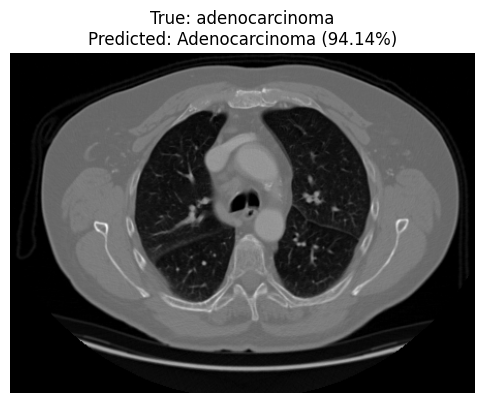

In [4]:
# CT Lung Cancer Prediction using EfficientNet-B0

# Import libraries
import torch
import timm
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Load Trained Checkpoint

checkpoint = torch.load(
    "/content/drive/MyDrive/Ashely CT Lungcancer Detection-V1/Ashely CT Lungcancer Detection-V1/models/efficientnet_focal_v1.pt",
    map_location=torch.device("cpu")
)

# Rebuild Model Architecture

model = timm.create_model(
    checkpoint["config"]["model"]["backbone"],
    pretrained=False,
    num_classes=checkpoint["config"]["data"]["num_classes"],
    drop_rate=checkpoint["config"]["model"]["dropout"]
)

# Load Trained Weights

model.load_state_dict(checkpoint["model_state"])

# Set model to evaluation mode
model.eval()

# Class Labels

classes = [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Normal",
    "Squamous Cell Carcinoma"
]

# Image Preprocessing

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load Correctly Predicted Images CSV


from pathlib import Path
import random

# Folder containing images
folder_path = Path(
    "/content/drive/MyDrive/Ashely CT Lungcancer Detection-V1/Ashely CT Lungcancer Detection-V1/Data-2/test/adenocarcinoma"
)

# Get all PNG images
image_files = list(folder_path.glob("*.png"))

# Select one random image
image_path = random.choice(image_files)

print("Selected Image:", image_path)

# True label from folder name
true_label = folder_path.name

# Load Image

image = Image.open(image_path).convert("RGB")

# Transform Image


input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)

# Prediction

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    predicted_class = torch.argmax(probabilities, dim=1).item()

    confidence = probabilities[0][predicted_class].item()

# Convert Index to Class Name

prediction = classes[predicted_class]

# Print Results

print("True Label:", true_label)
print("Predicted Class:", prediction)
print("Confidence:", f"{confidence:.2%}")

# Display Image with Prediction

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"True: {true_label}\nPredicted: {prediction} ({confidence:.2%})"
)

plt.axis("off")

plt.show()